In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [ ]:
!pip install -q transformers>=4.49.0 accelerate qwen-vl-utils==0.0.8 datasets pillow bitsandbytes

In [ ]:
import torch
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

min_pixels = 256 * 28 * 28
max_pixels = 1280 * 28 * 28

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels=min_pixels,
    max_pixels=max_pixels,
)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map={"": 0},
)
model.eval()
print("Model loaded on:", model.device)

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model loaded on: cuda:0


In [ ]:
import json, re

GROUNDING_PROMPT = (
    'You are looking at a screenshot that is {width}x{height} pixels.\n'
    'Find the UI element for this instruction: "{instruction}"\n'
    'Respond with ONLY a JSON object giving the pixel coordinate to click, '
    'in this exact format: {{"point": [x, y]}}\n'
    "x is measured from the left edge, y from the top edge. No other text."
)

def parse_point(text):
    try:
        match = re.search(r"\{.*\}", text, re.DOTALL)
        if match:
            obj = json.loads(match.group(0))
            pt = obj.get("point")
            if pt and len(pt) == 2:
                return float(pt[0]), float(pt[1])
    except Exception:
        pass
    nums = re.findall(r"-?\d+\.?\d*", text)
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return None

@torch.inference_mode()
def predict_click(image, instruction, max_new_tokens=128):
    image = image.convert("RGB")
    orig_w, orig_h = image.size

    messages = [{
        "role": "user",
        "content": [
            {"type": "image", "image": image, "min_pixels": min_pixels, "max_pixels": max_pixels},
            {"type": "text", "text": GROUNDING_PROMPT.format(width=orig_w, height=orig_h, instruction=instruction)},
        ],
    }]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    image_inputs, video_inputs = process_vision_info(messages)
    resized_w, resized_h = image_inputs[0].size

    inputs = processor(text=[text], images=image_inputs, videos=video_inputs, padding=True, return_tensors="pt").to(model.device)
    generated_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
    output_text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]

    point = parse_point(output_text)
    if point is None:
        return None
    x, y = point
    return x * (orig_w / resized_w), y * (orig_h / resized_h)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("rootsautomation/ScreenSpot")["test"]
sample = dataset[0]
print("Instruction:", sample["instruction"])
print("Ground-truth bbox (x1,y1,x2,y2):", sample["bbox"])

pred = predict_click(sample["image"], sample["instruction"])
print("Predicted point:", pred)

README.md:   0%|          | 0.00/3.50k [00:00<?, ?B/s]

data/test-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

data/test-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  199MB            

data/test-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  269MB            

data/test-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/1272 [00:00<?, ? examples/s]

Instruction: close
Ground-truth bbox (x1,y1,x2,y2): [0.9479166666666666, 0.14444444444444443, 0.99375, 0.2074074074074074]
Predicted point: (925.7142857142857, 88.30827067669173)


In [ ]:
from collections import defaultdict

samples_per_source = defaultdict(list)
for sample in dataset:
    src = sample["data_source"]
    if len(samples_per_source[src]) < 3:
        samples_per_source[src].append(sample)

for src, samples in samples_per_source.items():
    print(f"=== {src} ===")
    for sample in samples:
        img_w, img_h = sample["image"].size
        pred = predict_click(sample["image"], sample["instruction"])
        x1, y1, x2, y2 = sample["bbox"]
        x1, x2, y1, y2 = x1*img_w, x2*img_w, y1*img_h, y2*img_h
        hit = pred is not None and x1 <= pred[0] <= x2 and y1 <= pred[1] <= y2
        print("instruction:", sample["instruction"])
        print(f"bbox (px): [{x1:.0f}, {y1:.0f}, {x2:.0f}, {y2:.0f}]")
        print("predicted:", pred, " HIT:" , hit)
        print()

=== windows ===
instruction: close
bbox (px): [910, 78, 954, 112]
predicted: (925.7142857142857, 88.30827067669173)  HIT: True

instruction: minimize this window
bbox (px): [835, 0, 871, 30]
predicted: (844.0336134453781, 12.18045112781955)  HIT: True

instruction: play the solitaire collection
bbox (px): [258, 139, 1658, 371]
predicted: (608.3890577507599, 315.989010989011)  HIT: True

=== macos ===
instruction: check my apple id
bbox (px): [1025, 141, 1129, 268]
predicted: (1078.5918367346937, 195.92261904761907)  HIT: True

instruction: view the language & region settings
bbox (px): [1018, 368, 1139, 515]
predicted: (1084.0530612244897, 472.9166666666667)  HIT: True

instruction: open time machine
bbox (px): [859, 952, 972, 1105]
predicted: (914.7551020408163, 1025.5535714285716)  HIT: True

=== ios ===
instruction: check the weather
bbox (px): [223, 78, 824, 671]
predicted: (519.7619047619047, 377.6847290640394)  HIT: True

instruction: view world clock
bbox (px): [879, 75, 1478, 3

In [ ]:
from collections import defaultdict
import time, json, os

LIMIT = None
CHECKPOINT_FILE = "/content/repo/eval_progress.json"

def point_in_bbox(x, y, bbox, img_w, img_h):
    x1, y1, x2, y2 = bbox
    x1, x2 = x1 * img_w, x2 * img_w
    y1, y2 = y1 * img_h, y2 * img_h
    return x1 <= x <= x2 and y1 <= y <= y2

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        state = json.load(f)
    per_sample = state["per_sample"]
    correct_by_group = defaultdict(lambda: [0, 0], {k: v for k, v in state["correct_by_group"].items()})
    start_idx = len(per_sample)
    print(f"Resuming from sample {start_idx}")
else:
    per_sample = []
    correct_by_group = defaultdict(lambda: [0, 0])
    start_idx = 0

eval_set = dataset if LIMIT is None else dataset.select(range(min(LIMIT, len(dataset))))
start = time.time()

for i in range(start_idx, len(eval_set)):
    sample = eval_set[i]
    img_w, img_h = sample["image"].size
    pred = predict_click(sample["image"], sample["instruction"])
    hit = pred is not None and point_in_bbox(pred[0], pred[1], sample["bbox"], img_w, img_h)
    per_sample.append({"instruction": sample["instruction"], "prediction": pred, "correct": hit,
                        "data_type": sample["data_type"], "data_source": sample["data_source"]})
    for key in (f"type:{sample['data_type']}", f"source:{sample['data_source']}", "overall"):
        correct_by_group[key][1] += 1
        if hit:
            correct_by_group[key][0] += 1

    if (i + 1) % 20 == 0:
        print(f"{i+1}/{len(eval_set)}  ({time.time()-start:.0f}s elapsed)")
        with open(CHECKPOINT_FILE, "w") as f:
            json.dump({"per_sample": per_sample, "correct_by_group": dict(correct_by_group)}, f)
        !cd /content/repo && git add eval_progress.json && git commit -m "checkpoint at {i+1}" -q && git push -q

print("\n=== Results ===")
for group, (c, t) in sorted(correct_by_group.items()):
    print(f"{group:20s}  {c/t*100:5.1f}%  ({c}/{t})")

Resuming from sample 180
200/1272  (209s elapsed)
220/1272  (361s elapsed)
240/1272  (543s elapsed)
260/1272  (723s elapsed)
280/1272  (907s elapsed)
300/1272  (1090s elapsed)
320/1272  (1265s elapsed)
340/1272  (1449s elapsed)
360/1272  (1628s elapsed)
380/1272  (1810s elapsed)
400/1272  (1993s elapsed)
420/1272  (2175s elapsed)
440/1272  (2359s elapsed)
460/1272  (2541s elapsed)
480/1272  (2725s elapsed)
500/1272  (2911s elapsed)
520/1272  (3096s elapsed)
540/1272  (3280s elapsed)
560/1272  (3464s elapsed)
580/1272  (3650s elapsed)
600/1272  (3835s elapsed)
620/1272  (4017s elapsed)
640/1272  (4199s elapsed)
660/1272  (4383s elapsed)
680/1272  (4566s elapsed)
700/1272  (4750s elapsed)
720/1272  (4936s elapsed)
740/1272  (5120s elapsed)
760/1272  (5305s elapsed)
780/1272  (5491s elapsed)
800/1272  (5676s elapsed)
820/1272  (5859s elapsed)
840/1272  (6043s elapsed)
860/1272  (6222s elapsed)
880/1272  (6402s elapsed)
900/1272  (6581s elapsed)
920/1272  (6760s elapsed)
940/1272  (6939s e

In [ ]:
import json
with open("/content/final_results.json", "w") as f:
    json.dump({"per_sample": per_sample, "correct_by_group": dict(correct_by_group)}, f)

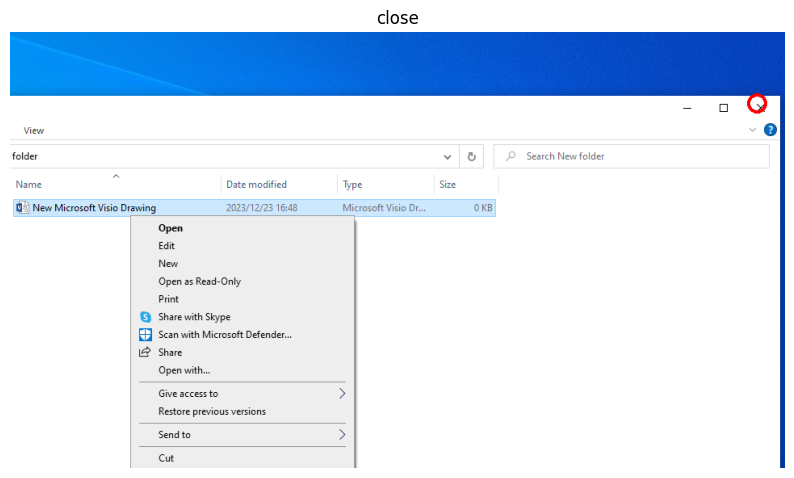

In [ ]:
from PIL import ImageDraw
import matplotlib.pyplot as plt

sample = dataset[0]
pred = predict_click(sample["image"], sample["instruction"])

marked = sample["image"].copy()
draw = ImageDraw.Draw(marked)
if pred:
    x, y = pred
    r = 12
    draw.ellipse([x-r, y-r, x+r, y+r], outline="red", width=4)

plt.figure(figsize=(10, 6))
plt.imshow(marked)
plt.title(sample["instruction"])
plt.axis("off")
plt.show()